In [2]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [200]:
from ml_from_scratch.base import Unsupervised

class KMeans(Unsupervised):
    def __init__(self, k=2, max_iter=100, save_centroid_updates=False):
        self.k = k
        self.max_iter = max_iter
        self.centroids = None
        self.save_centroid_updates = save_centroid_updates
        self.centroid_updates = None

    def fit(self, X):
        n_samples = X.shape[0]
        rng = np.random.default_rng()

        self.centroids = [X[np.random.choice(list(range(n_samples)))]]

        for _ in range(self.k - 1):
            dists = np.zeros(X.shape[0])
        
            for i, p in enumerate(X):
                dists[i] = np.min([np.sum((p - centroid) ** 2) for centroid in self.centroids]) ** 2
        
            total = np.sum(dists)
            threshold = rng.uniform(.0, total)
            cumulative_dists = np.cumsum(dists)
            self.centroids.append(
                X[np.where(cumulative_dists >= threshold)[0][0]]
            )

        self.centroids = np.asarray(self.centroids)
        if self.save_centroid_updates:
            self.centroid_updates = np.zeros((self.max_iter, *self.centroids.shape))

        for _ in range(max_iter):
            if self.save_centroid_updates:
                self.centroid_updates[_] = self.centroids
            labels = self.transform(X)
            self.centroids = np.array([np.mean(X[np.where(labels == label)], axis=0) for label in range(self.k)])

    def transform(self, X):
        return np.array(
            [np.argmin([np.sum((p - centroid) ** 2) for centroid in self.centroids]) for p in X]
        )

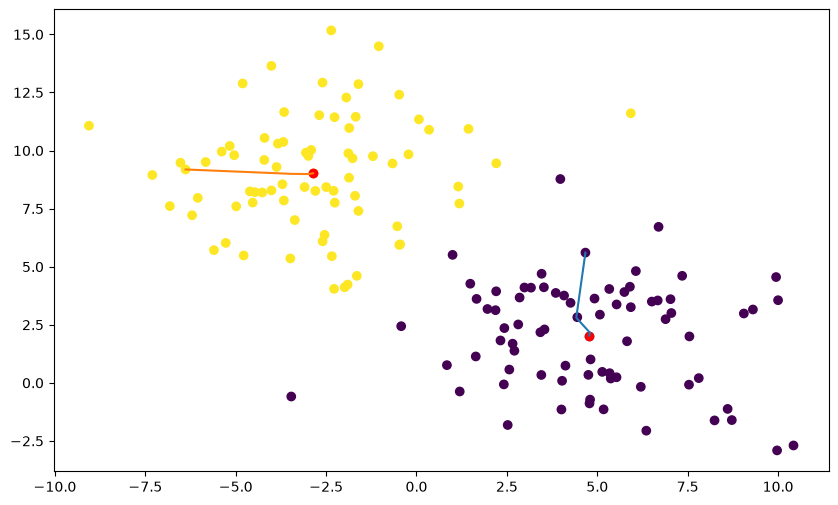

In [213]:
n_samples = 150
X, y = make_blobs(n_samples=n_samples, centers=2, n_features=2, random_state=42, cluster_std=2.5)

k = 2
model = KMeans(k=k, max_iter=200, save_centroid_updates=True)
model.fit(X)

plt.figure(figsize=(10, 6))
feature_0 = X[:, 0]
feature_1 = X[:, 1]

for j in range(k):
    trajectory = model.centroid_updates[:, j, :]
    
    plt.plot(trajectory[:, 0], trajectory[:, 1])
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1])
    
plt.scatter(feature_0, feature_1, c=model.transform(X))
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], color='red')

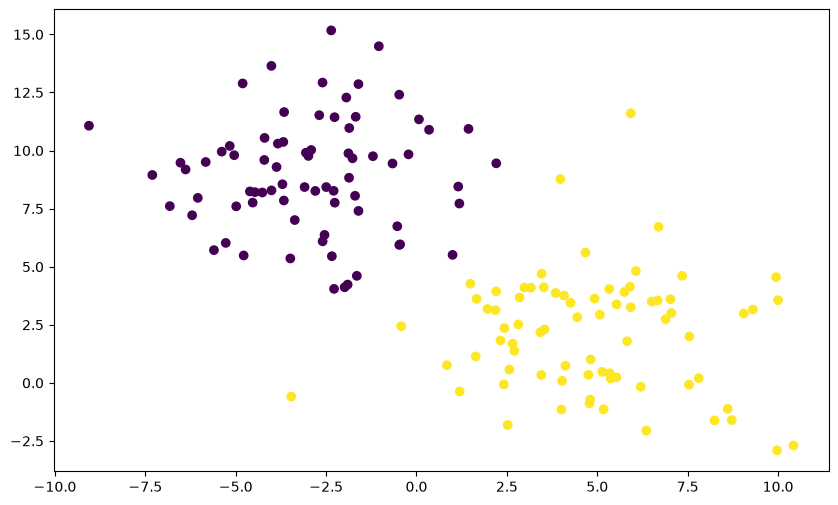

In [212]:
plt.figure(figsize=(10, 6))

plt.scatter(feature_0, feature_1, c=y)